## Task 1: Data Collection and Data Processing

### 1.1 Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Load Dataset

In [2]:
df = pd.read_csv('data/hanoi_air_quality.csv', parse_dates=['timestamp'])

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (8760, 14)
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00

Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'is_weekend', 'wind_direction', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25']


,timestamp,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
0,2025-01-01 00:00:00,14.1,91,1.138889,1016.6,0,2,0,319,0.0,0,1,158,111.3
1,2025-01-01 01:00:00,13.5,93,1.277778,1016.6,1,2,0,321,0.0,4,1,159,112.7
2,2025-01-01 02:00:00,12.9,94,1.083333,1016.1,2,2,0,317,0.0,0,1,160,113.2
3,2025-01-01 03:00:00,12.6,96,1.277778,1015.5,3,2,0,315,0.0,0,1,162,113.9
4,2025-01-01 04:00:00,12.4,96,1.277778,1015.4,4,2,0,312,0.0,2,1,163,115.5


### 1.3 Data Collection Description

Data was collected using the **Open-Meteo API** (https://open-meteo.com), a free and open-source weather API that provides hourly historical data.

- **Source:** Open-Meteo Weather Archive API + Air Quality API
- **Location:** Hanoi, Vietnam (lat: 21.0285, lon: 105.8542)
- **Period:** 1 year of hourly data
- **Collection method:** Automated API requests via Python (`collect_data.py`)

**Features collected:**

| Feature | Description | Unit | Type |
|---|---|---|---|
| `temperature` | Air temperature at 2m | °C | Compulsory |
| `humidity` | Relative humidity | % | Compulsory |
| `wind_speed` | Wind speed at 10m | m/s | Compulsory |
| `pressure` | Atmospheric pressure | hPa | Compulsory |
| `hour` | Hour of day | 0–23 | Compulsory |
| `day_of_week` | Day of week | 0–6 | Compulsory |
| `is_weekend` | Is weekend | 0/1 | Backup |
| `wind_direction` | Wind direction | degrees | Backup |
| `precipitation` | Precipitation | mm | Backup |
| `cloud_cover` | Cloud cover | % | Backup |

**Target variable:** `is_warning` - AQI > 100 (Unhealthy for Sensitive Groups)

**Validation variable (not used in model):** `aqi` and `pm25` were collected for target construction and post-hoc interpretation only. They are not used as model input features because `aqi` directly defines the warning label and `pm25` is a pollutant measurement rather than a meteorological predictor.

**Data privacy:** No personal data was collected. All data is publicly available environmental measurements.

### 1.4 Data Processing

The cleaned dataset contains 8,760 hourly observations. No missing values or duplicate rows were found, so no observations were removed. The binary target `is_warning` was verified to match the rule `AQI > 100`, confirming that AQI directly defines the warning label. Therefore, `aqi` and `pm25` were retained only for target construction and post-hoc interpretation, and were excluded from all supervised and unsupervised model inputs to avoid data leakage.

In [3]:
# Check missing values
print('Missing Values')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values
timestamp         0
temperature       0
humidity          0
wind_speed        0
pressure          0
hour              0
day_of_week       0
is_weekend        0
wind_direction    0
precipitation     0
cloud_cover       0
is_warning        0
aqi               0
pm25              0
dtype: int64

Total missing: 0


In [4]:
# Drop rows with missing values in compulsory columns
compulsory_cols = ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'aqi', 'pm25']
before = len(df)
df = df.dropna(subset=compulsory_cols).reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with missing values in compulsory columns')
print(f'Remaining rows: {len(df)}')

Dropped 0 rows with missing values in compulsory columns
Remaining rows: 8760


In [5]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dropped {duplicates} duplicate rows')

Duplicate rows: 0


In [6]:
# Feature encoding
# is_weekend and is_warning are already binary (0/1)
# No additional encoding needed for numerical features

print('Feature dtypes:')
print(df.dtypes)

Feature dtypes:
timestamp         datetime64[us]
temperature              float64
humidity                   int64
wind_speed               float64
pressure                 float64
hour                       int64
day_of_week                int64
is_weekend                 int64
wind_direction             int64
precipitation            float64
cloud_cover                int64
is_warning                 int64
aqi                        int64
pm25                     float64
dtype: object


In [7]:
df.to_csv('data/hanoi_air_quality_clean.csv', index=False)
print('Saved clean data → data/hanoi_air_quality_clean.csv')

Saved clean data → data/hanoi_air_quality_clean.csv


### 1.5 Data Visualization

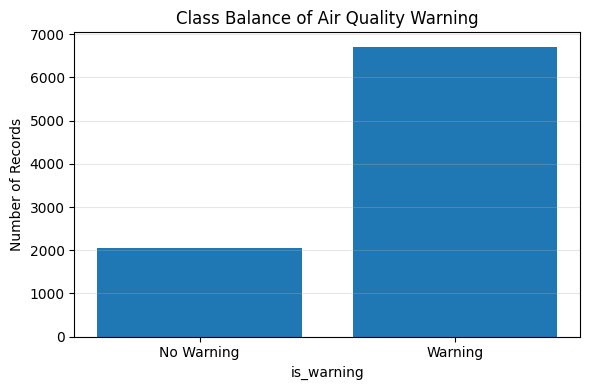

is_warning
0    2051
1    6709
Name: count, dtype: int64


In [ ]:
# Distributions: Class balance bar chart
# Label = is_warning
class_counts = df["is_warning"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Warning", "Warning"], class_counts.values)
plt.title("Class Balance of Air Quality Warning")
plt.xlabel("is_warning")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("visuals/task1_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()

print(class_counts)

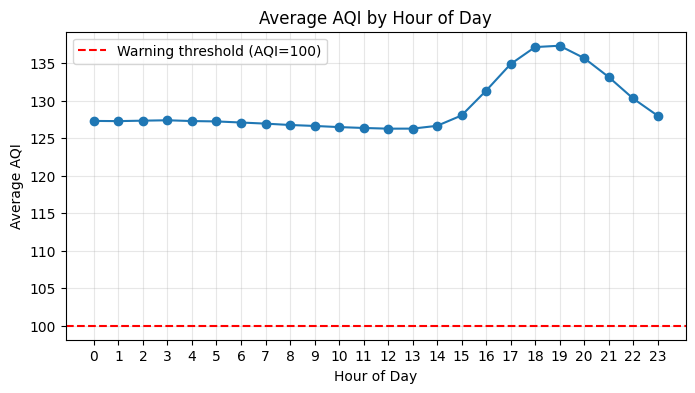

In [16]:
hourly_aqi = df.groupby("hour")["aqi"].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o")
plt.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Warning threshold (AQI=100)')
plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("visuals/task1_aqi_byhour.png", dpi=300, bbox_inches="tight")
plt.show()

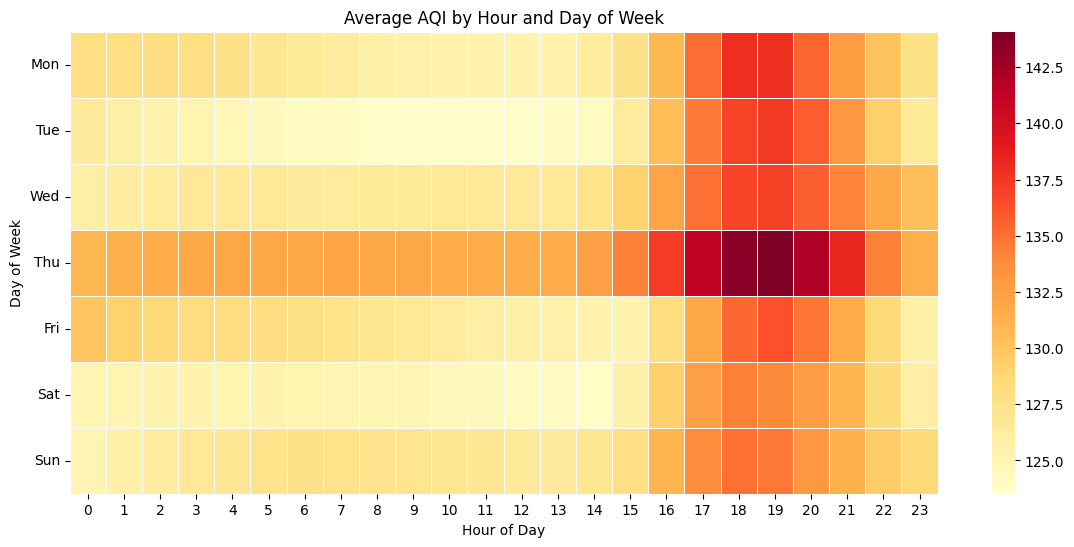

In [17]:
# Heatmap: Average AQI by Hour and Day of Week
day_order = [0, 1, 2, 3, 4, 5, 6]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

heatmap_data = df.pivot_table(
    values="aqi",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(index=day_order, columns=range(24))

plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=False
)

ax.set_yticklabels(day_labels, rotation=0)

plt.title("Average AQI by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.savefig("visuals/task1_aqi_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

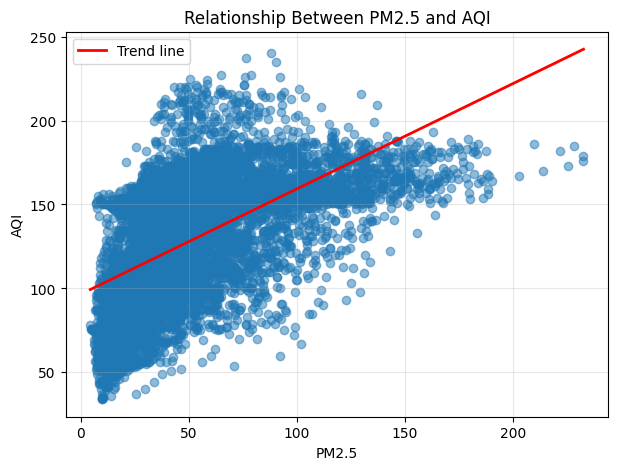

In [18]:
# Scatter plot: PM2.5 vs AQI with trend line
from numpy.polynomial.polynomial import polyfit

plt.figure(figsize=(7, 5))
plt.scatter(df["pm25"], df["aqi"], alpha=0.5)

# Trend line
z = np.polyfit(df["pm25"], df["aqi"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["pm25"].min(), df["pm25"].max(), 100)
plt.plot(x_line, p(x_line), color="red", linewidth=2, label="Trend line")

plt.title("Relationship Between PM2.5 and AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("visuals/task1_pm25_aqi_rela.png", dpi=300, bbox_inches="tight")
plt.show()

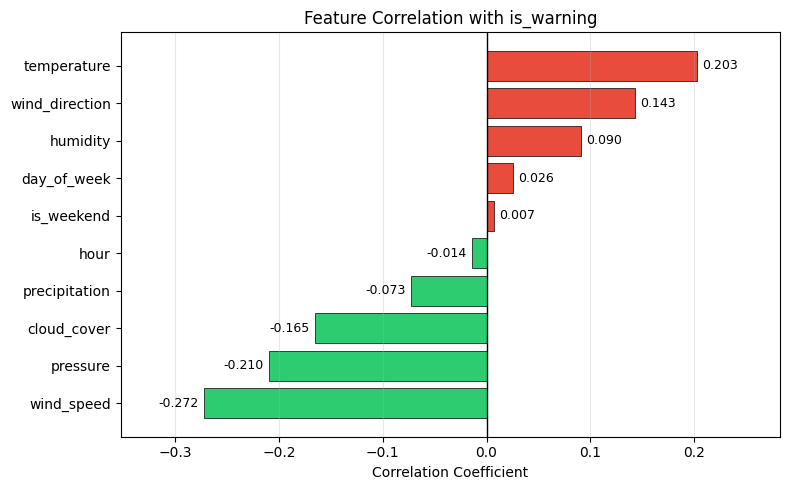

In [19]:
# Feature Correlation with is_warning
feature_cols = ["temperature", "humidity", "wind_speed", "pressure",
                "hour", "day_of_week", "is_weekend",
                "wind_direction", "precipitation", "cloud_cover"]

correlations = df[feature_cols].corrwith(df["is_warning"]).sort_values()

plt.figure(figsize=(8, 5))
bars = plt.barh(correlations.index, correlations.values,
                color=["#e74c3c" if x > 0 else "#2ecc71" for x in correlations.values],
                edgecolor="black", linewidth=0.5)

# Add value labels
for bar, val in zip(bars, correlations.values):
    plt.text(val + 0.005 if val >= 0 else val - 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

plt.axvline(x=0, color="black", linewidth=1)
plt.title("Feature Correlation with is_warning")
plt.xlabel("Correlation Coefficient")
plt.xlim(correlations.min() - 0.08, correlations.max() + 0.08)  # thêm dòng này
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("visuals/task1_feature_corre.png", dpi=300, bbox_inches="tight")
plt.show()

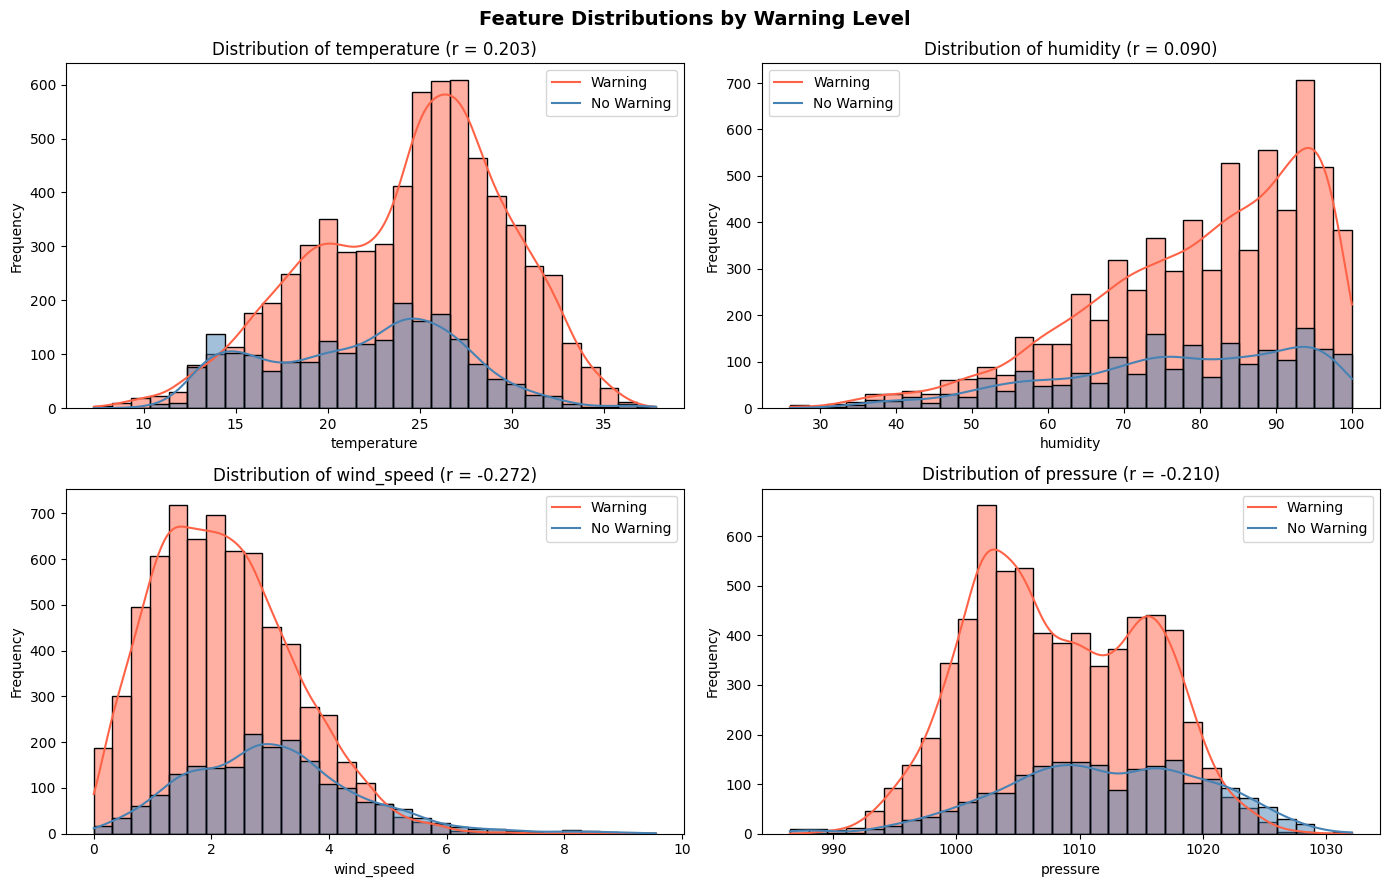

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

numeric_cols = ["temperature", "humidity", "wind_speed", "pressure"]

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="is_warning", bins=30, kde=True,
                 ax=axes[i], palette={0: "steelblue", 1: "tomato"},
                 alpha=0.5)
    corr = df[col].corr(df["is_warning"])
    axes[i].set_title(f"Distribution of {col} (r = {corr:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(labels=["Warning", "No Warning"])

plt.suptitle("Feature Distributions by Warning Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visuals/task1_feature_distribute.png", dpi=300, bbox_inches="tight")
plt.show()